In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

In [2]:
sns.set(style="whitegrid", context="notebook")
DATA_PATH = 'malnutrition_children_ethiopia.csv'

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,ID,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Stunting,Underweight,Overweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
0,1,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,2,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,3,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,4,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,5,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [5]:
df.columns = [c.strip().replace(' ', '_').replace('(', '').replace(')', '').lower() for c in df.columns]
df.head()

,id,age_months,gender,region,mother_education,household_wealth_index,height_cm,weight_kg,stunting,underweight,overweight,anemia,malaria,diarrhea,tb,nutrition_status
0,1,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,2,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,3,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,4,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,5,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [6]:
print("Shape:", df.shape)
display(df.dtypes)
display(df.head())

Shape: (4098, 16)


id                          int64
age_months                  int64
gender                     object
region                     object
mother_education           object
household_wealth_index     object
height_cm                 float64
weight_kg                 float64
stunting                    int64
underweight                 int64
overweight                  int64
anemia                      int64
malaria                     int64
diarrhea                    int64
tb                          int64
nutrition_status           object
dtype: object

,id,age_months,gender,region,mother_education,household_wealth_index,height_cm,weight_kg,stunting,underweight,overweight,anemia,malaria,diarrhea,tb,nutrition_status
0,1,31,Male,Amhara,Higher,Middle,84.1,19.2,1,1,0,1,1,1,1,At_Risk
1,2,38,Female,Tigray,Higher,Middle,91.0,6.3,0,0,0,0,1,1,0,Normal
2,3,7,Female,SNNPR,Secondary,Middle,61.4,5.8,1,1,1,1,1,0,1,Normal
3,4,7,Female,Amhara,Higher,Low,103.1,12.9,1,0,1,1,0,1,0,Normal
4,5,0,Male,Tigray,No education,High,78.9,7.4,0,0,0,0,1,1,0,Normal


In [8]:
# check if there any missing values
# Cell 3 - missingness
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean()*100).round(2).sort_values(ascending=False)
missing = pd.concat([missing_count, missing_pct], axis=1)
missing.columns = ['missing_count','missing_pct']
missing.head(20)

,missing_count,missing_pct
id,0,0.0
age_months,0,0.0
gender,0,0.0
region,0,0.0
mother_education,0,0.0
household_wealth_index,0,0.0
height_cm,0,0.0
weight_kg,0,0.0
stunting,0,0.0
underweight,0,0.0


In [9]:
# verify the target varibale and find for duplicates
target = 'nutrition_status' 
print("Target value counts:")
display(df[target].value_counts(dropna=False))
print("Duplicate rows:", df.duplicated().sum())

Target value counts:


nutrition_status
Normal          2030
At_Risk         1238
Malnourished     830
Name: count, dtype: int64

Duplicate rows: 0


In [10]:
# summary in numerical format
num_cols = df.select_dtypes(include=['number']).columns.tolist()
display(df[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
id,4098.0,2049.500000,1183.135030,1.0,1025.25,2049.5,3073.75,4098.0
age_months,4098.0,29.691557,17.357813,0.0,15.00,29.5,45.00,59.0
height_cm,4098.0,84.532113,14.620986,60.0,71.90,84.3,97.10,110.0
weight_kg,4098.0,12.475915,4.358932,5.0,8.70,12.4,16.30,20.0
stunting,4098.0,0.502928,0.500052,0.0,0.00,1.0,1.00,1.0
underweight,4098.0,0.493655,0.500021,0.0,0.00,0.0,1.00,1.0
overweight,4098.0,0.499024,0.500060,0.0,0.00,0.0,1.00,1.0
anemia,4098.0,0.503904,0.500046,0.0,0.00,1.0,1.00,1.0
malaria,4098.0,0.504148,0.500044,0.0,0.00,1.0,1.00,1.0
diarrhea,4098.0,0.497560,0.500055,0.0,0.00,0.0,1.00,1.0


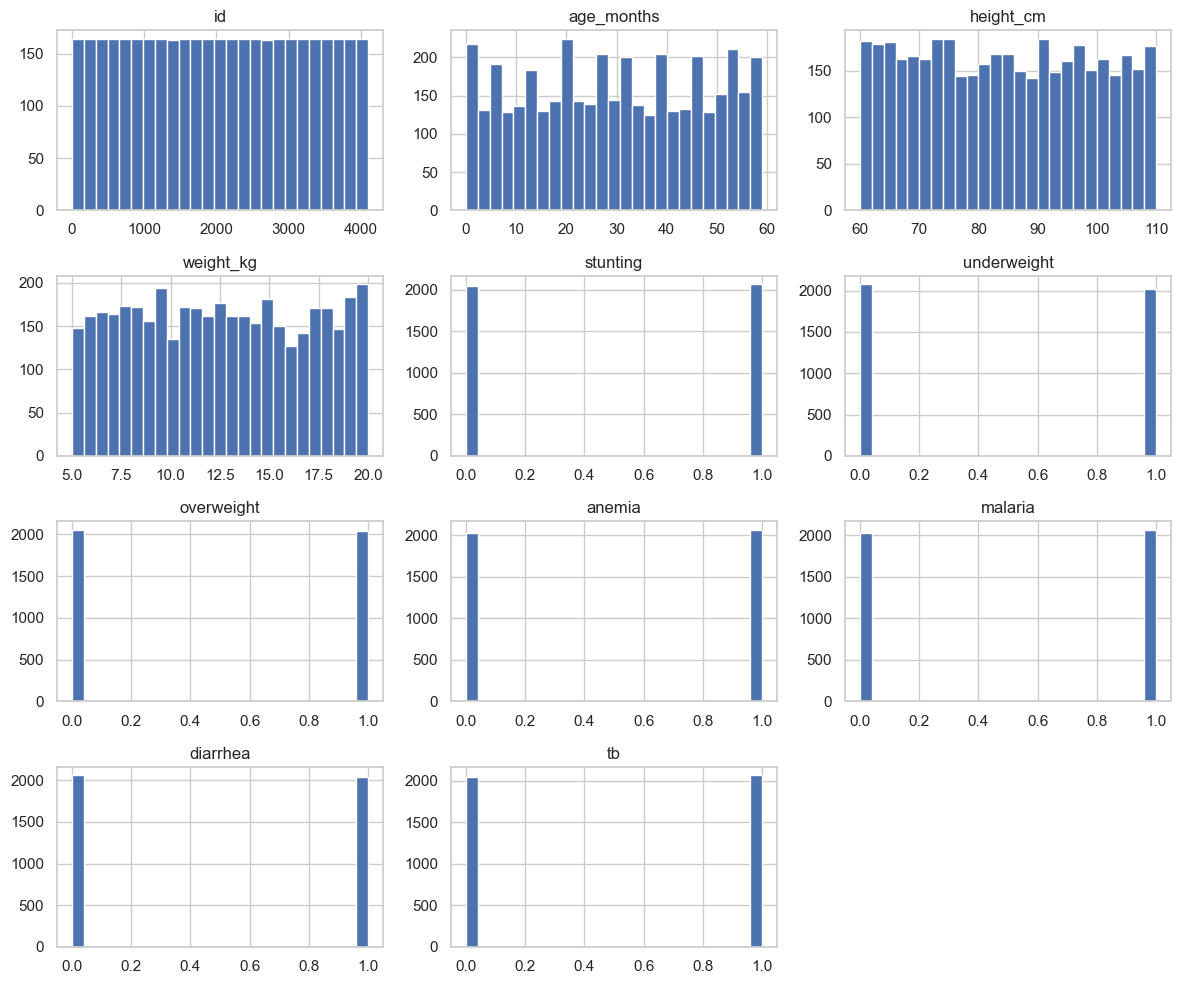

In [11]:
df[num_cols].hist(bins=25, figsize=(12,10))
plt.tight_layout()
plt.show()

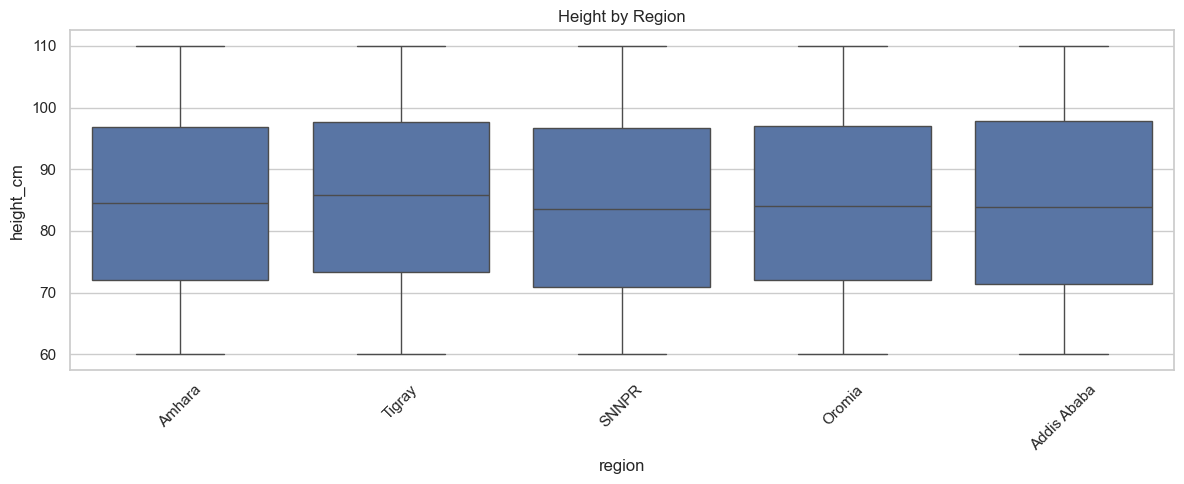

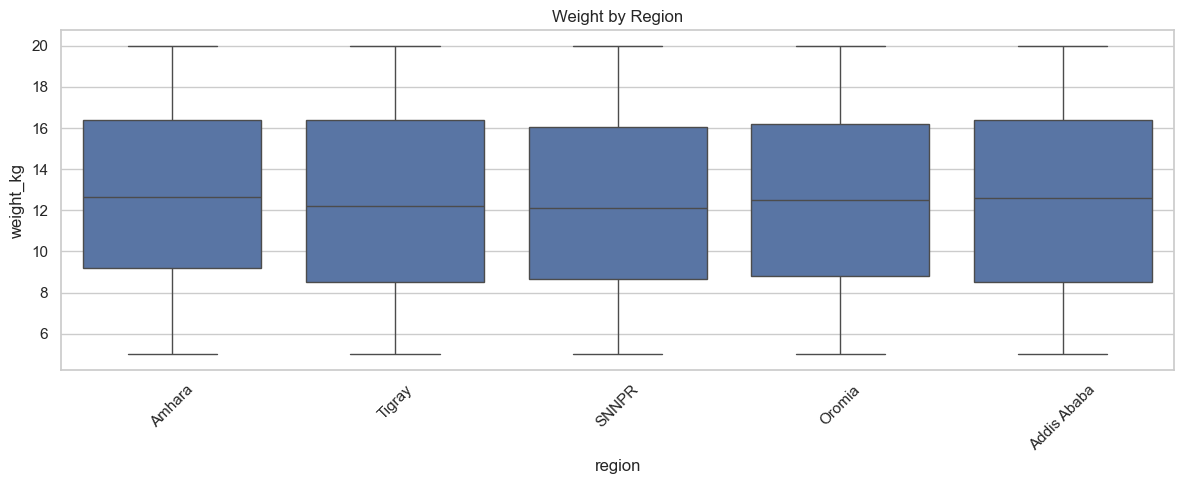

In [12]:
# Cell 6 - boxplots height/weight by region
plt.figure(figsize=(12,5))
sns.boxplot(x='region', y='height_cm', data=df)
plt.xticks(rotation=45)
plt.title('Height by Region')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='region', y='weight_kg', data=df)
plt.xticks(rotation=45)
plt.title('Weight by Region')
plt.tight_layout()
plt.show()


In [13]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    print(f"--- {c} ---")
    display(df[c].value_counts().head(10))

--- gender ---


gender
Male      2066
Female    2032
Name: count, dtype: int64

--- region ---


region
Amhara         852
SNNPR          835
Addis Ababa    808
Tigray         803
Oromia         800
Name: count, dtype: int64

--- mother_education ---


mother_education
Secondary       1052
Primary         1047
Higher          1010
No education     989
Name: count, dtype: int64

--- household_wealth_index ---


household_wealth_index
Low       1404
High      1369
Middle    1325
Name: count, dtype: int64

--- nutrition_status ---


nutrition_status
Normal          2030
At_Risk         1238
Malnourished     830
Name: count, dtype: int64

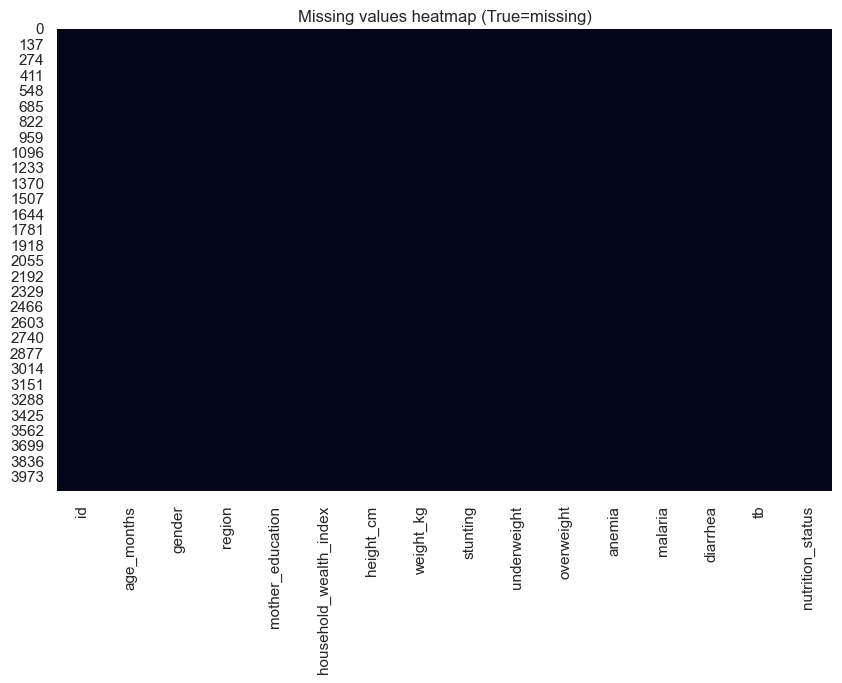

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing values heatmap (True=missing)')
plt.show()

In [15]:
from scipy import stats
num_cols = [c for c in num_cols if c in df.columns]
z = np.abs(stats.zscore(df[num_cols].dropna()))
# rows with any z>3
outlier_rows = (z > 3).any(axis=1)
print("Outlier rows detected (z>|3|):", outlier_rows.sum())
# show a few outliers
display(df.loc[df.index[outlier_rows]].head())

Outlier rows detected (z>|3|): 0


,id,age_months,gender,region,mother_education,household_wealth_index,height_cm,weight_kg,stunting,underweight,overweight,anemia,malaria,diarrhea,tb,nutrition_status


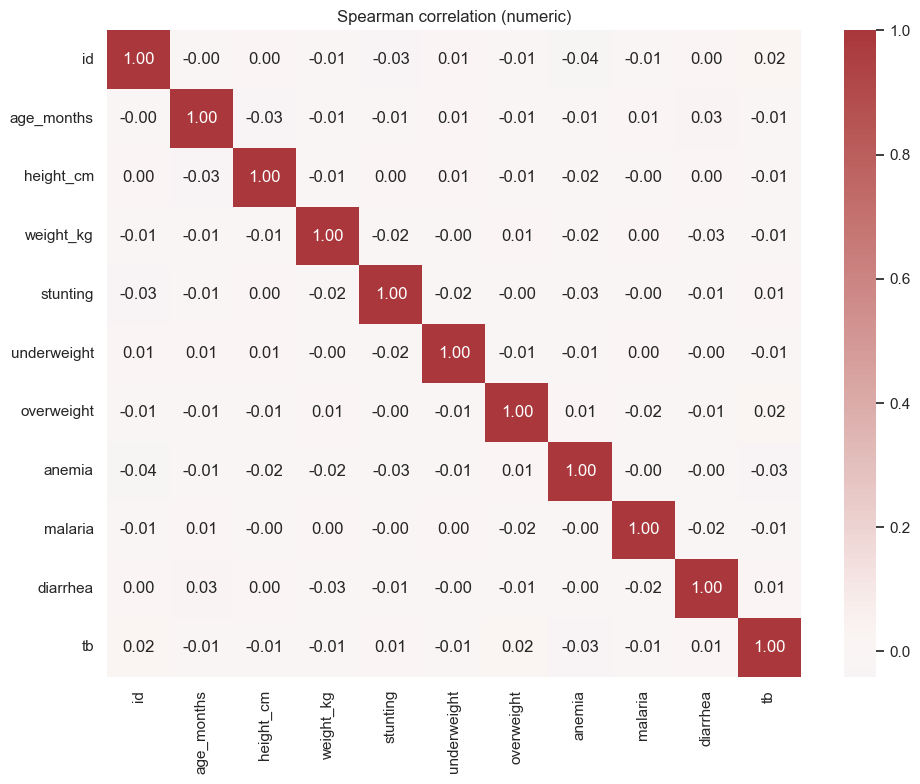

In [16]:
corr = df[num_cols].corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0)
plt.title('Spearman correlation (numeric)')
plt.tight_layout()
plt.show()